In [1]:
import pandas as pd
import numpy as np

In [ ]:
import tensorflow as tf # type:ignore
from tensorflow.keras import Sequential # type:ignore
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Dropout # type:ignore
from tensorflow.keras.regularizers import l2 # type:ignore
from tensorflow.keras.callbacks import EarlyStopping # type:ignore
from tensorflow.keras.optimizers import Adam # type:ignore

In [3]:
train = "C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Cats vs Dogs\\train"
test = "C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Cats vs Dogs\\test"

In [4]:
# Generators: Used to convert data in batches so RAM can process easily. Also it used to rescale the image on the same scale.

def ImageTransformation(train,test):

    train_generator = tf.keras.utils.image_dataset_from_directory(
        directory = train,
        labels = "inferred",
        label_mode = "int", # Assigning 0 to cats and 1 to dogs
        batch_size = 33,
        image_size = (180,180)
    )

    test_generator = tf.keras.utils.image_dataset_from_directory(
        directory = test,
        labels = "inferred",
        label_mode = "int", # Assigning 0 to cats and 1 to dogs
        batch_size = 33,
        image_size = (180,180)
    )

    # Normalization: Every val in numpy array is between 0 and 255, we will convert it between 0 and 1.

    def Transformation(img, label):
        img = tf.cast(img/255, tf.float32)
        return img,label

    train_pixels = train_generator.map(Transformation)
    test_pixels = test_generator.map(Transformation)

    return train_pixels, test_pixels

train_pixels, test_pixels = ImageTransformation(train, test)

Found 8000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
def dataset_to_numpy(dataset):

    images = []
    labels = []

    for img_batch, label_batch in dataset:
        images.append(img_batch.numpy())
        labels.append(label_batch.numpy())

    X = np.concatenate(images, axis=0)
    y = np.concatenate(labels, axis=0)
    
    return X, y

trainx, trainy = dataset_to_numpy(train_pixels)
testx, testy = dataset_to_numpy(test_pixels)

print(trainx.shape, trainy.shape)
print(testx.shape, testy.shape)

(8000, 180, 180, 3) (8000,)
(2000, 180, 180, 3) (2000,)


In [6]:
# CNN Model:

def build_model(meta):

    input_shape = meta["X_shape_"][1:]

    m = Sequential()

    m.add(Conv2D(32, kernel_size=(3,3), padding="same", activation="relu", input_shape = input_shape))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(pool_size=(2,2), padding = "valid", strides = 2))

    m.add(Conv2D(64, kernel_size=(3,3), padding="same", activation="relu"))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(pool_size=(2,2), padding = "valid", strides = 2))

    m.add(Conv2D(128, kernel_size=(3,3), padding="same", activation="relu"))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(pool_size=(2,2), padding = "valid", strides = 2))

    m.add(Conv2D(128, kernel_size=(3,3), padding="same", activation="relu"))
    m.add(BatchNormalization())
    m.add(MaxPooling2D(pool_size=(2,2), padding = "valid", strides = 2))    

    m.add(Flatten())

    m.add(Dense(128, activation="relu",kernel_regularizer=l2(0.005))) # First layer
    m.add(Dropout(0.3))
    m.add(Dense(64, activation="relu",kernel_regularizer=l2(0.005))) # Second layer
    m.add(Dropout(0.3))
    m.add(Dense(1, activation="sigmoid")) # Output layer

    m.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.0003), metrics=["accuracy"]) # Using Adam gradient descent as optimizer

    return m

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
import os
import warnings

warnings.filterwarnings('ignore')
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # Suppress INFO, WARNING, and ERROR logs from TF/absl

from scikeras.wrappers import KerasClassifier
from sklearn.metrics import accuracy_score

m = KerasClassifier(model=build_model, epochs=15, batch_size=33, verbose=1, validation_split=0.3, callbacks=[early_stop])

m.fit(trainx,trainy)

Epoch 1/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.6234 - loss: 2.2607 - val_accuracy: 0.5004 - val_loss: 3.3123
Epoch 2/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.7027 - loss: 1.7218 - val_accuracy: 0.6471 - val_loss: 1.6523
Epoch 3/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7330 - loss: 1.4167 - val_accuracy: 0.7292 - val_loss: 1.3192
Epoch 4/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7754 - loss: 1.1540 - val_accuracy: 0.7358 - val_loss: 1.1384
Epoch 5/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8184 - loss: 0.9389 - val_accuracy: 0.7608 - val_loss: 0.9904
Epoch 6/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8354 - loss: 0.8028 - val_accuracy: 0.7700 - val_loss: 0.8728
Epoch 7/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.8643 - loss: 0.6848 - val_accuracy: 0.7958 - val_loss: 0.7796
Epoch 8/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8882 - loss: 0.5846 - val_accu

KerasClassifier(
	model=<function build_model at 0x000001F741895300>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=33
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000001F741AC9450>]
	validation_split=0.3
	shuffle=True
	run_eagerly=False
	epochs=15
	class_weight=None
)

In [9]:
predy = m.predict(testx) 
print("Accuarcy Score:", accuracy_score(testy, predy))

61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step
Accuarcy Score: 0.8105


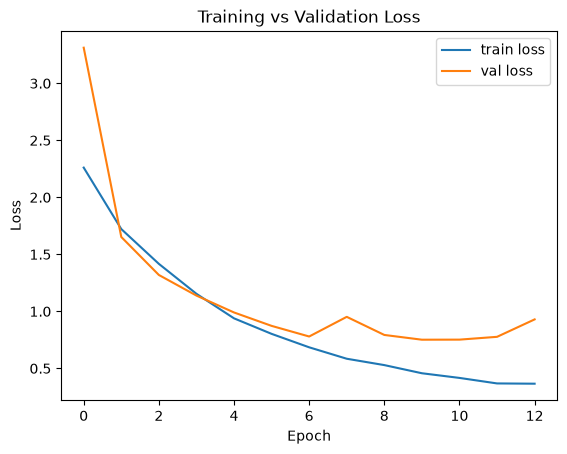

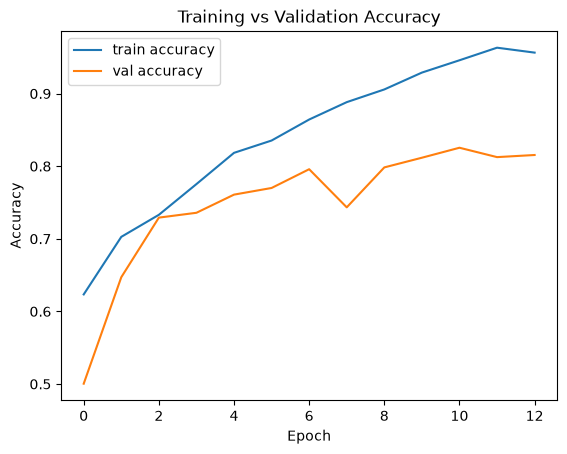

In [10]:
import matplotlib.pyplot as plt

# Plot of Loss
plt.figure()
plt.plot(m.history_["loss"], label="train loss")
plt.plot(m.history_["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot of Accuracy
plt.figure()
plt.plot(m.history_["accuracy"], label="train accuracy")
plt.plot(m.history_["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

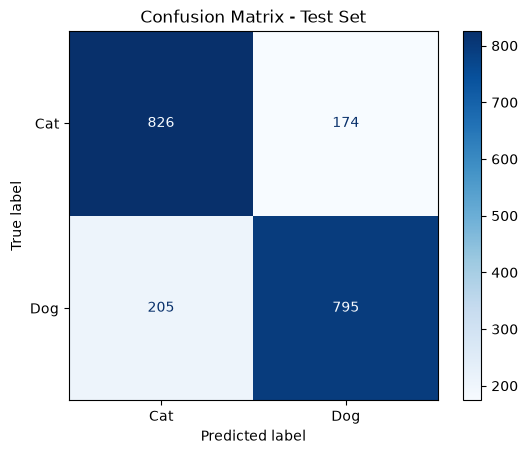

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(testy, predy)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cat", "Dog"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

# The confusion matrix plot shows counts of correct/incorrect predictions per class (true cats predicted as cats/dogs, 
# true dogs predicted as cats/dogs) — useful for spotting if the model is biased toward one class.

In [13]:
from tensorflow.keras.preprocessing import image

# Cat Prediction:

def predict_image(img_path, model, image_size=(180, 180)):

    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img)
    
    # Same normalization as our Transformation function
    img_array = tf.cast(img_array / 255, tf.float32)

    img_array = tf.reshape(img_array, (1,180,180,3)) # Add Batch dimension
    
    prediction = model.predict(img_array)
    label = "Dog" if prediction[0] == 1 else "Cat"
    print("Prediction:", label)

predict_image("C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Cats vs Dogs\\Final_test\\cat0.jpg", m)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: Cat


In [14]:
# Dog Prediction:

def predict_image(img_path, model, image_size=(180, 180)):

    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img)
    
    # Same normalization as our Transformation function
    img_array = tf.cast(img_array / 255, tf.float32)

    img_array = tf.reshape(img_array, (1,180,180,3)) # Add Batch dimension
    
    prediction = model.predict(img_array)
    label = "Dog" if prediction[0] == 1 else "Cat"
    print("Prediction:", label)
    
predict_image("C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Cats vs Dogs\\Final_test\\dog0.jpg", m)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction: Dog
